# **Card & Krueger (1994) Difference-in-Difference Causal Analysis**

### **Context:**
"On April 1, 1992, New Jersey's minimum wage rose from $4.25 to $5.05 per hour. To evaluate the impact of the law we surveyed 410 fast-food restaurants in New Jersey and eastern Pennsylvania before and after the rise. Comparisons of employment growth at stores in New Jersey and Pennsylvania (where the minimum wage was constant) provide simple estimates of the effect of the higher minimum wage. We also compare employment changes at stores in New Jersey that were initially paying high wages (above $5) to the changes at lower-wage stores. We find no indication that the rise in the minimum wage reduced employment" (David Card and Alan B. Krueger).

### **Links:**

https://davidcard.berkeley.edu/papers/njmin-aer.pdf?utm_source=chatgpt.com

https://davidcard.berkeley.edu/data_sets.html?utm_source=chatgpt.com

**Simplified Dataset Used:** https://www.ssc.wisc.edu/~bhansen/econometrics/CK1994.dta?utm_source=chatgpt.com 

### **Description:**

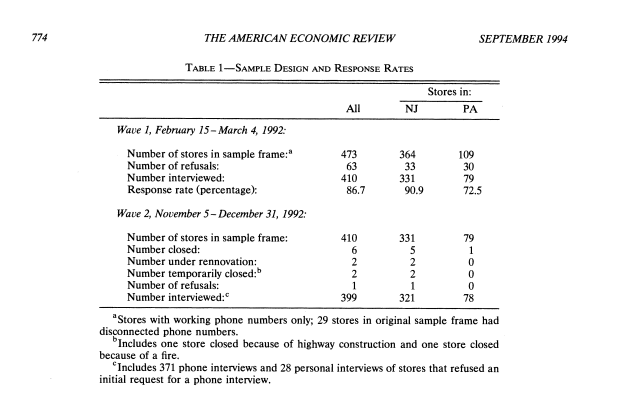

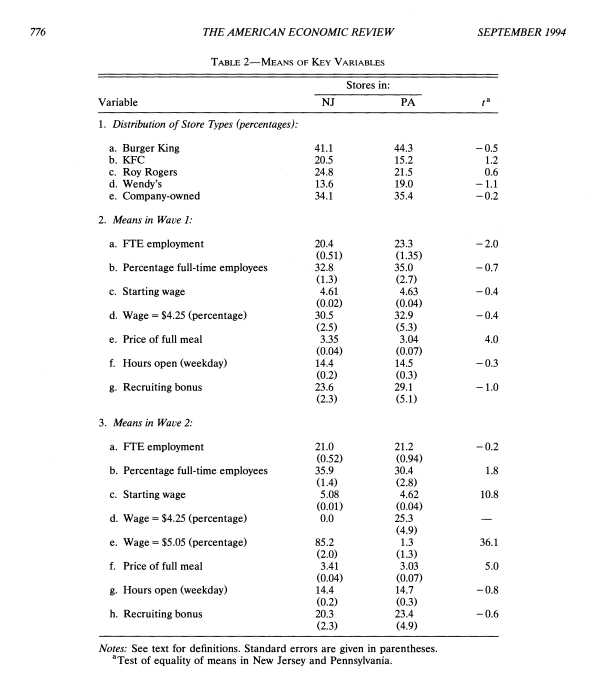

### **Columns:**
1) state
    - 1 = New Jersey.
    - 0 = Pennsylvania.
2) empft
    - Number of full-time employees.
3) emppt
    - Number of part-time employees.
4) nmgrs
    - Number of managers.
5) time
    - 1 = After the minimum wage increase from $4.25 to $5.05 per hour.
    - 0 = Before the minimum wage increase from $4.25 to $5.05 per hour.

### **Analysis:**
1) Difference in Difference (DID) Design Causal Analysis.

---

## **Importing Packages and Reading Dataset:**

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm

In [99]:
df = pd.read_stata("C:\BROCK U COURSE DOCS\DataSets\CK1994 (1).dta")
df.head()

,store,chain,co_owned,state,southj,centralj,northj,pa1,pa2,shore,ncalls,empft,emppt,nmgrs,wage_st,inctime,firstinc,meals,open,hoursopen,pricesoda,pricefry,priceentree,nregisters,nregisters11,time
0,46.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,30.0,15.0,3.0,NaN,19.0,NaN,2.0,6.5,16.5,1.03,1.03,0.52,3.0,3.0,0.0
1,49.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.5,6.5,4.0,NaN,26.0,NaN,2.0,10.0,13.0,1.01,0.90,2.35,4.0,3.0,0.0
2,506.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,7.0,2.0,NaN,13.0,0.37,2.0,11.0,10.0,0.95,0.74,2.33,3.0,3.0,0.0
3,56.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,20.0,20.0,4.0,5.0,26.0,0.10,2.0,10.0,12.0,0.87,0.82,1.79,2.0,2.0,0.0
4,61.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.0,26.0,5.0,5.5,52.0,0.15,3.0,10.0,12.0,0.87,0.77,1.65,2.0,2.0,0.0


## **Exploring Data:**

In [100]:
df.duplicated().sum()

np.int64(0)

> No duplicated rows to to remove.

In [101]:
df.isna().sum()

store             0
chain             0
co_owned          0
state             0
southj            0
centralj          0
northj            0
pa1               0
pa2               0
shore             0
ncalls          249
empft            18
emppt            14
nmgrs            12
wage_st          41
inctime          97
firstinc        123
meals            11
open             11
hoursopen        11
pricesoda        30
pricefry         45
priceentree      36
nregisters       28
nregisters11     39
time              0
dtype: int64

> The columns state and time do not have any NaN values.
>
> However, full time employment has 18, part time employment has 14, and managers have 12.
>
> These NaN values must be dealt with.

In [102]:
df = df.dropna(subset= ['empft', 'emppt', 'nmgrs'])
df.isna().sum()

store             0
chain             0
co_owned          0
state             0
southj            0
centralj          0
northj            0
pa1               0
pa2               0
shore             0
ncalls          246
empft             0
emppt             0
nmgrs             0
wage_st          34
inctime          89
firstinc        110
meals             6
open              7
hoursopen         7
pricesoda        25
pricefry         41
priceentree      32
nregisters       22
nregisters11     33
time              0
dtype: int64


---

## **Getting Columns for Analysis, and Constructing Full-Time Equivalent (FTE) Column:**

### **Columns to be Used:**
1) state
    - 1 = New Jersey.
    - 0 = Pennsylvania.
2) empft
    - Number of full-time employees.
3) emppt
    - Number of part-time employees.
4) nmgrs
    - Number of managers.
5) time
    - 1 = After the minimum wage increase from $4.25 to $5.05 per hour.
    - 0 = Before the minimum wage increase from $4.25 to $5.05 per hour.
6) Full-Time Equivalent (FTE) Measure Column:
    - A calculated column not found within the dataset.
    - FTE = empft + (0.5 * emppt) + nmgrs
    - Both managers and full-time employees both work full-time hours.
    - Part-time employees work about half as much as full-time workers.
    - Therefore, it takes two part-time employees to equal one full-time worker / manager.
    - Hence (0.5 * emppt).

In [103]:
df_used = df[['state', 'time']].copy()

df_used['fte'] = df['empft'] + (0.5 * df['emppt']) + df['nmgrs']

df_used

,state,time,fte
0,0.0,0.0,40.50
1,0.0,0.0,13.75
2,0.0,0.0,8.50
3,0.0,0.0,34.00
4,0.0,0.0,24.00
...,...,...,...
815,1.0,1.0,23.75
816,1.0,1.0,17.50
817,1.0,1.0,20.50
818,1.0,1.0,20.50



---

## **Difference in Difference (DID) Design Causal Analysis:**

### **Causal Statement: An increase in minimum wage will cause a decrease in employment.**
- This is assumed because higher wages may lead to high costs for employers.
- If it costs more for employers to have employees work, then employers will have less employees at work.
- An increase in wages will cause a decrease in employment and an increase in unemployment.


### **Reasoning for Assumption:**
- The assumption that an increase in minimum wage will cause a decrease in employment has been a well rooted topic in classical economic thinking.
- The theory of price floor states that if a price is set for labour or products, it can prevent the overall market price from reaching perfect equilibrium.
- An employee who works less and is lazy should be paid much lower than one who works hard and is motivated.
- However, minimum wage prevents employers from lowering the lazy worker's wage to their deserved equilibrium.
- But, it allows employers to raise the price above minimum wage for those who work hard.

https://en.wikipedia.org/wiki/Price_floor


### **DID Design:**
- The perpose of difference-in-difference design for evaluating average treatment effect is that we compare the treatment and control groups before and after treatment is assigned.
- We compare the control and treatment groups before treatment is assigned to the treated, and then we compare the control and treatment groups after treatment is assigned to the treated.
- If there is a large difference between the treated and control groups after treatment occurs, and the average treatment effect showing this is statistically significant, then we can conclude there does perhaps exist an estimated causal effect between the treatment x and outcome y.
- This designed model allows us to look at both groups at all times before and after treatment. Perfect for policy making.

> **Linear Regression Equation:** y = $\beta_0$ + $\beta_1$ $D_i$ + $\beta_2$ $P_t$ + $\beta_3$ ($D_i$ * $P_t$) + $\epsilon_{it}$

y = The outcome

$\beta_0$ = The average outcome of the control group before treatment.

$\beta_1$ = The change in average for the treated group before treatment.

$D_i$ = The treatment, where 1 = treated, and 0 = control.

$\beta_2$ = The change in average of control group after treatment.

$P_t$ = The post, where 1 = after treatment and 0 = before treatment.

$\beta_3$ = The Average Treatment Effect on the Treated (ATT). Measures the change in the outcome from the treated group after treatment. This is the estimated causal effect.

($D_i$ * $P_t$) = The treatment when treated (D = 1) AND after treatment (P = 1)

$\epsilon_{it}$ = The error term. Includes all cofounders. However, cofounders are equally destributed accross treatment and control groups in before and after treatment times. 

Therefore, E[$\epsilon_{it}$] = 0, COV($\epsilon_{it}$, $D_i$) = 0, and cov($\epsilon_{it}$, $P_t$) = 0.


### **DID Design for Card & Krueger (1994) Data:**

> **Linear Regression Equation:** Full Time Equivalent Employees = $\beta_0$ + $\beta_1$ (State) + $\beta_2$ (Time) + $\beta_3$ (State * Time) + $\epsilon_{it}$

Outcome = Number of full time equivalent (fte) employees.

$D_i$ Treatment = State, where 1 = New Jersey and 0 = Pennsylvania.

$P_t$ Post = Time, where 1 = After treatment (minimum wage increase to $5.05/hour) and 0 = Before treatment (minimum wage is $4.25/hour).

In [104]:
y = df_used['fte']

x = df_used[['state', 'time']]
x['state_time'] = df_used['state'] * df_used['time']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    fte   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.964
Date:                Wed, 05 Aug 2026   Prob (F-statistic):              0.118
Time:                        20:14:01   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.3312      1.072     21.767      0.000      21.227      25.435
state         -2.8918      1.194     -2.423      0.016      -5.235      -0.549
time          -2.1656      1.516     -1.429      0.154      -5.141       0.810
state_time     2.7536      1.688      1.631      0.103      -0.561       6.068
==============================================================================
Omnibus:                      218.742   Durbin-Watson:                   1.840
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              804.488
Skew:                           1.268   Prob(JB):                    2.03e-175
Kurtosis:                       7.229   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Conclusion:**

> **Linear Regression Equation:** Full Time Equivalent Employees = 23.3312 -2.8918 (State) -2.1656 (Time) + 2.7536 (State * Time) + $\epsilon_{it}$

- The average treatment effect of the treated (ATT) is 2.7536.
- What this means is that the average increase in full time equivalent employees is 2.75 in the city of New Jersey after minimum wage is increased from $4.25 to $5.05 per hour.
- The original assumption, which stated that an increase in minimum wage will cause a decrease in employment, has proven to be incorrect.
- When minimum wage increases in the treated location of New Jersey, the number of employees working increases by 2.75 on average. Unemployment decreases while employment increases.
- However, the relationship is statistically insignificant and therefore we cannot infer a causal effect.

Ho: The population average treatment effect of the treated (ATT) $\beta_3$ = 0

Ha: The population average treatment effect of the treated (ATT) $\beta_3$ != 0

t-stat = ($\beta_3$ - 0) / SE

t-stat = (2.7536 - 0) / 1.688

t-stat = 1.631

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.103

$\alpha$ = 0.05

=> p-value > $\alpha$

=> 0.103 > 0.05

=> We fail to reject the null hypothesis; the population average treatment effect of the treated (ATT) $\beta_3$ = 0.

- The difference between the sample average treatment effect of the treated (ATT) and zero, given the standard error (standard deviation of the test statistic), is very low and is close to zero.
- The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true, is therefore very high.
- This is because we assume the population $\beta_3$ is zero, and the sample data for the estimated $\beta_3$ confirms this.
- The sample $\beta_3$ is close to zero, which verifies the assumption of the null hypothesis, and therefore the null hypothesis best represents the sample data stating the population $\beta_3$ is zero.
- Therefore the probability for observing this test statistic is higher than 0.05 since it is in line with the assumption of the existance of the null hypothesis.

Confidence Interval for $\beta_3$ = [$\beta_3$ - (Z(0.05) * SE), $\beta_3$ + (Z(0.05) * SE)]

Confidence Interval for $\beta_3$ = [2.7536 - (1.96 * 1.688), 2.7536 + (1.96 * 1.688)]

Confidence Interval for $\beta_3$ = [-0.561, 6.068]

- The confidence interval confirms what has been shown in the hypothesis test for the average treatment effect of the treated.
- This interval shows the range the population $\beta_3$ will likely fall in during 95% of n repeated trials.
- Zero falls within this interval, so the population $\beta_3$ will likely be zero.


**To Conclude:**

- The assumption an increase in minimum wage will cause a decrease in employment is incorrect.
- The difference in difference designed regression model for causal effect analysis states that the relationship between minimum wage and number of employed workers is positive.
- As minimum wage per hour increases from $4.25 to $5.05 in the treated city of New Jersey, the number of employed full time equivalent workers increases by 2.7536.
- However, there does not exist a causal effect between the two variables given the statistical insignificance of the average treatment effect on the treated.
- The p-value for $\beta_3$ is 0.103, which is greater than 0.05 and therefore we reject the null hypothesis.
- The population average treatment effect of the treated (ATT) $\beta_3$ is zero.